In [ ]:
!pip install pafy youtube-dl moviepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 67.3 MB/s eta 0:00:00


In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-zt83ijj3
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-zt83ijj3
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install torch torchvision

In [ ]:
!pip install pytube

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
from pytube import YouTube

from PIL import Image
import torch
import clip
from torchvision import transforms
from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.optimizers import Adam





  if event.key is 'enter':



In [ ]:
seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [ ]:
# Downlaod the UCF101 Dataset
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

#Extract the Dataset
!unrar x UCF101.rar

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi             62%  OK 
Extracting  UCF-101/Pla

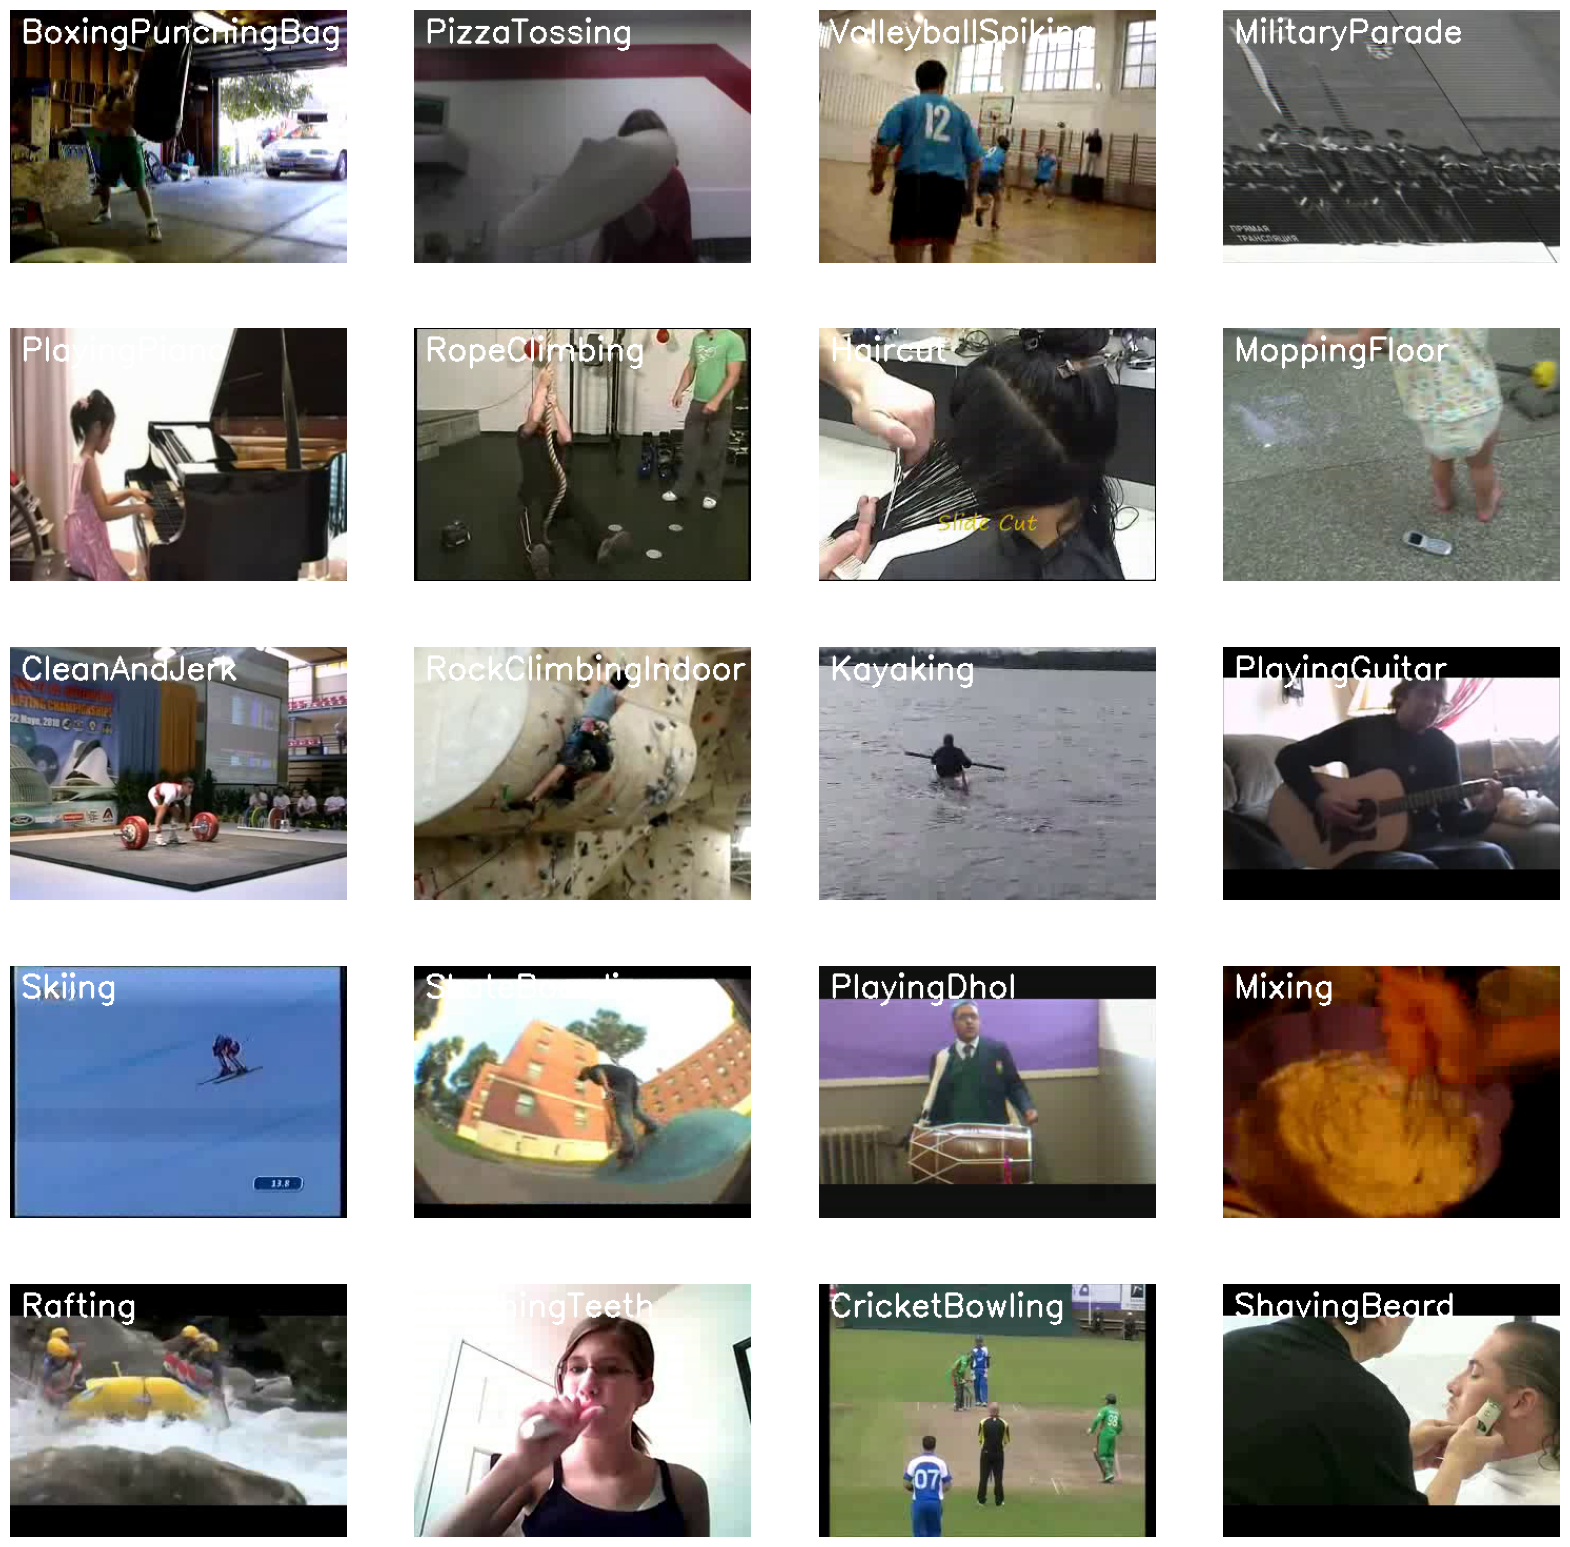

In [ ]:
# Tạo một hình ảnh Matplotlib và chỉ định kích thước của hình ảnh.
plt.figure(figsize=(20, 20))

# Lấy tên của tất cả các lớp/danh mục trong UCF101.
all_classes_names = os.listdir('UCF-101')

# Tạo một danh sách gồm 20 giá trị ngẫu nhiên. Các giá trị sẽ nằm trong khoảng từ 0-50,
# với 50 là tổng số lớp trong tập dữ liệu.
random_range = random.sample(range(len(all_classes_names)), 20)

# Lặp qua tất cả các giá trị ngẫu nhiên được tạo.
for counter, random_index in enumerate(random_range, 1):

    # Lấy tên lớp bằng cách sử dụng chỉ mục ngẫu nhiên.
    selected_class_Name = all_classes_names[random_index]

    # Lấy danh sách tất cả các tệp video có trong thư mục lớp ngẫu nhiên đã chọn.
    video_files_names_list = os.listdir(f'UCF-101/{selected_class_Name}')

    # Chọn ngẫu nhiên một tệp video từ danh sách lấy từ thư mục lớp ngẫu nhiên đã chọn.
    selected_video_file_name = random.choice(video_files_names_list)

    # Khởi tạo một đối tượng VideoCapture để đọc từ tệp video.
    video_reader = cv2.VideoCapture(f'UCF-101/{selected_class_Name}/{selected_video_file_name}')

    # Đọc khung hình đầu tiên của tệp video.
    _, bgr_frame = video_reader.read()

    # Giải phóng đối tượng VideoCapture.
    video_reader.release()

    # Chuyển đổi khung hình từ định dạng BGR sang định dạng RGB.
    rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

    # Ghi tên lớp lên khung hình video.
    cv2.putText(rgb_frame, selected_class_Name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Hiển thị khung hình.
    plt.subplot(5, 4, counter)
    plt.imshow(rgb_frame)
    plt.axis('off')


In [ ]:
# Chỉ định chiều cao và chiều rộng mà mỗi khung hình video sẽ được thay đổi kích thước trong tập dữ liệu của chúng ta.
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224

# Chỉ định số lượng khung hình của một video sẽ được đưa vào mô hình dưới dạng một chuỗi.
SEQUENCE_LENGTH = 20

# Chỉ định thư mục chứa tập dữ liệu UCF101.
DATASET_DIR = "UCF-101"
BATCH_SIZE = 8
EPOCHS = 100
# Danh sách các lớp trong tập dữ liệu UCF101.
# Các lớp này có thể được tạo động từ thư mục hoặc định nghĩa tĩnh như bên dưới.
CLASSES_LIST = [
    "ApplyEyeMakeup", "ApplyLipstick", "Archery", "BabyCrawling",
    "BandMarching", "BaseballPitch", "Basketball", "BasketballDunk", "BenchPress",
    "Biking", "Billiards", "BlowDryHair", "BlowingCandles", "BodyWeightSquats",
    "Bowling", "BoxingPunchingBag", "BoxingSpeedBag", "BrushingTeeth", "CliffDiving", "CricketBowling", "CricketShot", "CuttingInKitchen",
    "Diving", "Drumming",
    "FrontCrawl", "GolfSwing", "Haircut", "Hammering",
    "HammerThrow",  "HandstandWalking", "HeadMassage", "HighJump",
    "HorseRace", "HulaHoop", "IceDancing", "JavelinThrow",
    "JugglingBalls", "Kayaking", "Knitting",
    "LongJump",  "MilitaryParade", "Mixing", "MoppingFloor",
    "Nunchucks", "ParallelBars", "PizzaTossing", "PlayingCello", "PlayingGuitar", "PlayingPiano",
    "PlayingSitar", "PlayingTabla", "PlayingViolin", "PommelHorse",
    "PullUps", "Punch", "PushUps", "Rafting",
    "Rowing",
    "SkateBoarding", "Skiing", "Skijet", "SkyDiving", "SoccerJuggling",
    "SoccerPenalty", "StillRings", "SumoWrestling", "Swing",
    "TableTennisShot", "TaiChi", "TennisSwing", "ThrowDiscus", "TrampolineJumping",
    "Typing", "VolleyballSpiking", "WalkingWithDog", "WallPushups",
    "WritingOnBoard", "YoYo"
]
# CLASSES_LIST = [
#     "ApplyEyeMakeup"
# ]



In [ ]:
def load_clip_model():
    """
    Tải mô hình CLIP
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Sử dụng thiết bị: {device}")
    model, preprocess = clip.load("ViT-B/32", device=device)
    return model, preprocess, device

In [ ]:
def frames_extraction(video_path):
    """
    Trích xuất các khung hình từ video với kích thước phù hợp với CLIP
    """
    # Khai báo danh sách lưu trữ khung hình
    frames_list = []

    # Đọc video file
    video_reader = cv2.VideoCapture(video_path)

    # Lấy tổng số khung hình trong video
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Tính toán khoảng cách giữa các khung hình được trích xuất
    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)

    # Lặp qua khung hình của video
    for frame_counter in range(SEQUENCE_LENGTH):
        # Đặt vị trí của khung hình cần đọc
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        # Đọc khung hình
        success, frame = video_reader.read()

        # Kiểm tra nếu khung hình được đọc thành công
        if not success:
            break

        # Resize khung hình phù hợp với đầu vào CLIP
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

        # Chuyển BGR sang RGB
        rgb_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB)

        # Chuẩn hóa pixel giá trị (0-1)
        normalized_frame = rgb_frame / 255.0

        # Thêm khung hình vào danh sách
        frames_list.append(normalized_frame)

    # Giải phóng video reader
    video_reader.release()

    # Kiểm tra nếu không lấy đủ số khung hình
    if len(frames_list) < SEQUENCE_LENGTH:
        # Bổ sung thêm khung trống
        frames_list = frames_list + [np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3))] * (SEQUENCE_LENGTH - len(frames_list))

    # Trả về danh sách khung hình đã chuẩn hóa
    return frames_list

In [ ]:
def extract_clip_features(frames_array, clip_model, preprocess, device):
    """
    Trích xuất đặc trưng CLIP từ các khung hình

    Args:
        frames_array: Mảng numpy với shape (sequence_length, height, width, channels)

    Returns:
        Đặc trưng CLIP với shape (sequence_length, embedding_dim)
    """
    sequence_length = frames_array.shape[0]
    embedding_dim = 512  # Kích thước embedding của CLIP (ViT-B/32)

    # Khởi tạo mảng để lưu các đặc trưng CLIP
    clip_features = np.zeros((sequence_length, embedding_dim))

    # Trích xuất đặc trưng cho từng khung hình
    with torch.no_grad():
        for i in range(sequence_length):
            # Chuyển đổi sang định dạng PIL Image
            frame = frames_array[i] * 255  # Rescale về khoảng [0, 255]
            frame = np.uint8(frame)
            pil_image = Image.fromarray(frame)

            # Áp dụng tiền xử lý CLIP
            preprocessed_image = preprocess(pil_image).unsqueeze(0).to(device)

            # Trích xuất đặc trưng
            features = clip_model.encode_image(preprocessed_image)

            # Lưu đặc trưng
            clip_features[i] = features.cpu().numpy()

    return clip_features

In [ ]:
def create_clip_dataset(clip_model, preprocess, device, sample_size=None):
    """
    Tạo tập dữ liệu với đặc trưng được trích xuất từ CLIP

    Args:
        sample_size: Số lượng video mẫu mỗi lớp (None để sử dụng tất cả)
    """
    # Khởi tạo danh sách để lưu trữ đặc trưng, nhãn và đường dẫn video
    clip_features_list = []
    labels = []
    video_files_paths = []

    # Lặp qua tất cả các lớp
    for class_index, class_name in enumerate(CLASSES_LIST):
        # Hiển thị thông tin về lớp đang xử lý
        print(f'Đang trích xuất đặc trưng cho lớp: {class_name}')

        # Lấy danh sách file video trong thư mục lớp
        files_list = os.listdir(os.path.join(DATASET_DIR, class_name))

        # Lấy mẫu ngẫu nhiên nếu được chỉ định
        if sample_size is not None:
            files_list = random.sample(files_list, min(sample_size, len(files_list)))

        # Lặp qua từng file video
        for file_name in files_list:
            # Lấy đường dẫn đầy đủ của file video
            video_file_path = os.path.join(DATASET_DIR, class_name, file_name)

            # Trích xuất khung hình từ video
            frames = frames_extraction(video_file_path)

            # Kiểm tra xem số khung hình có đúng không
            if len(frames) == SEQUENCE_LENGTH:
                # Chuyển danh sách khung hình thành mảng numpy
                frames_array = np.array(frames)

                # Trích xuất đặc trưng CLIP từ các khung hình
                video_clip_features = extract_clip_features(frames_array, clip_model, preprocess, device)

                # Thêm đặc trưng CLIP, nhãn và đường dẫn video vào danh sách
                clip_features_list.append(video_clip_features)
                labels.append(class_index)
                video_files_paths.append(video_file_path)

    # Chuyển đổi danh sách thành mảng numpy
    clip_features_array = np.array(clip_features_list)
    labels_array = np.array(labels)

    return clip_features_array, labels_array, video_files_paths


In [ ]:
# Tải mô hình CLIP
print("Đang tải mô hình CLIP...")
clip_model, clip_preprocess, device = load_clip_model()
print("Đã tải mô hình CLIP thành công!")

# Tạo tập dữ liệu với đặc trưng CLIP
print("Đang tạo tập dữ liệu...")
clip_features, labels, video_files_paths = create_clip_dataset(clip_model, clip_preprocess, device)

Đang tải mô hình CLIP...
Sử dụng thiết bị: cpu


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 139MiB/s]


Đã tải mô hình CLIP thành công!
Đang tạo tập dữ liệu...
Đang trích xuất đặc trưng cho lớp: ApplyEyeMakeup
Đang trích xuất đặc trưng cho lớp: ApplyLipstick
Đang trích xuất đặc trưng cho lớp: Archery
Đang trích xuất đặc trưng cho lớp: BabyCrawling
Đang trích xuất đặc trưng cho lớp: BandMarching
Đang trích xuất đặc trưng cho lớp: BaseballPitch
Đang trích xuất đặc trưng cho lớp: Basketball
Đang trích xuất đặc trưng cho lớp: BasketballDunk
Đang trích xuất đặc trưng cho lớp: BenchPress
Đang trích xuất đặc trưng cho lớp: Biking
Đang trích xuất đặc trưng cho lớp: Billiards
Đang trích xuất đặc trưng cho lớp: BlowDryHair
Đang trích xuất đặc trưng cho lớp: BlowingCandles
Đang trích xuất đặc trưng cho lớp: BodyWeightSquats
Đang trích xuất đặc trưng cho lớp: Bowling
Đang trích xuất đặc trưng cho lớp: BoxingPunchingBag
Đang trích xuất đặc trưng cho lớp: BoxingSpeedBag
Đang trích xuất đặc trưng cho lớp: BrushingTeeth
Đang trích xuất đặc trưng cho lớp: CliffDiving
Đang trích xuất đặc trưng cho lớp: Cr

In [ ]:
# Using Keras's to_categorical method to convert labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

In [ ]:
clip_features_train, clip_features_test, labels_train, labels_test = train_test_split(clip_features, one_hot_encoded_labels, test_size = 0.25, shuffle = True, random_state = seed_constant)

In [ ]:
def create_LRCN_model():
    model = Sequential()

    # Lớp đầu vào cho các đặc trưng CLIP
    model.add(Input(shape=(SEQUENCE_LENGTH, 512)))  # 512 là kích thước embedding của CLIP

    # Xử lý các đặc trưng CLIP với các lớp tf.keras.layers.LSTM
    # Disable CuDNN by setting activation and recurrent_activation
    model.add(tf.keras.layers.LSTM(128, return_sequences=True, activation='tanh', recurrent_activation='sigmoid', unroll=False, use_bias=True))
    model.add(tf.keras.layers.Dropout(0.3))
    model.add(tf.keras.layers.LSTM(64, activation='tanh', recurrent_activation='sigmoid', unroll=False, use_bias=True))
    model.add(tf.keras.layers.Dropout(0.3))

    # Các lớp phân loại - Đã thay đổi lớp Dense cuối cùng
    model.add(tf.keras.layers.Dense(len(CLASSES_LIST), activation='softmax'))

    model.summary()
    return model

In [ ]:
# Xây dựng mô hình CLIP-LRCN cần thiết.
clip_lrcn_model = create_LRCN_model()

# Hiển thị thông báo thành công.
print("Mô hình CLIP-LRCN đã được tạo thành công!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 382,670 (1.46 MB)

 Trainable params: 382,670 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

Mô hình CLIP-LRCN đã được tạo thành công!


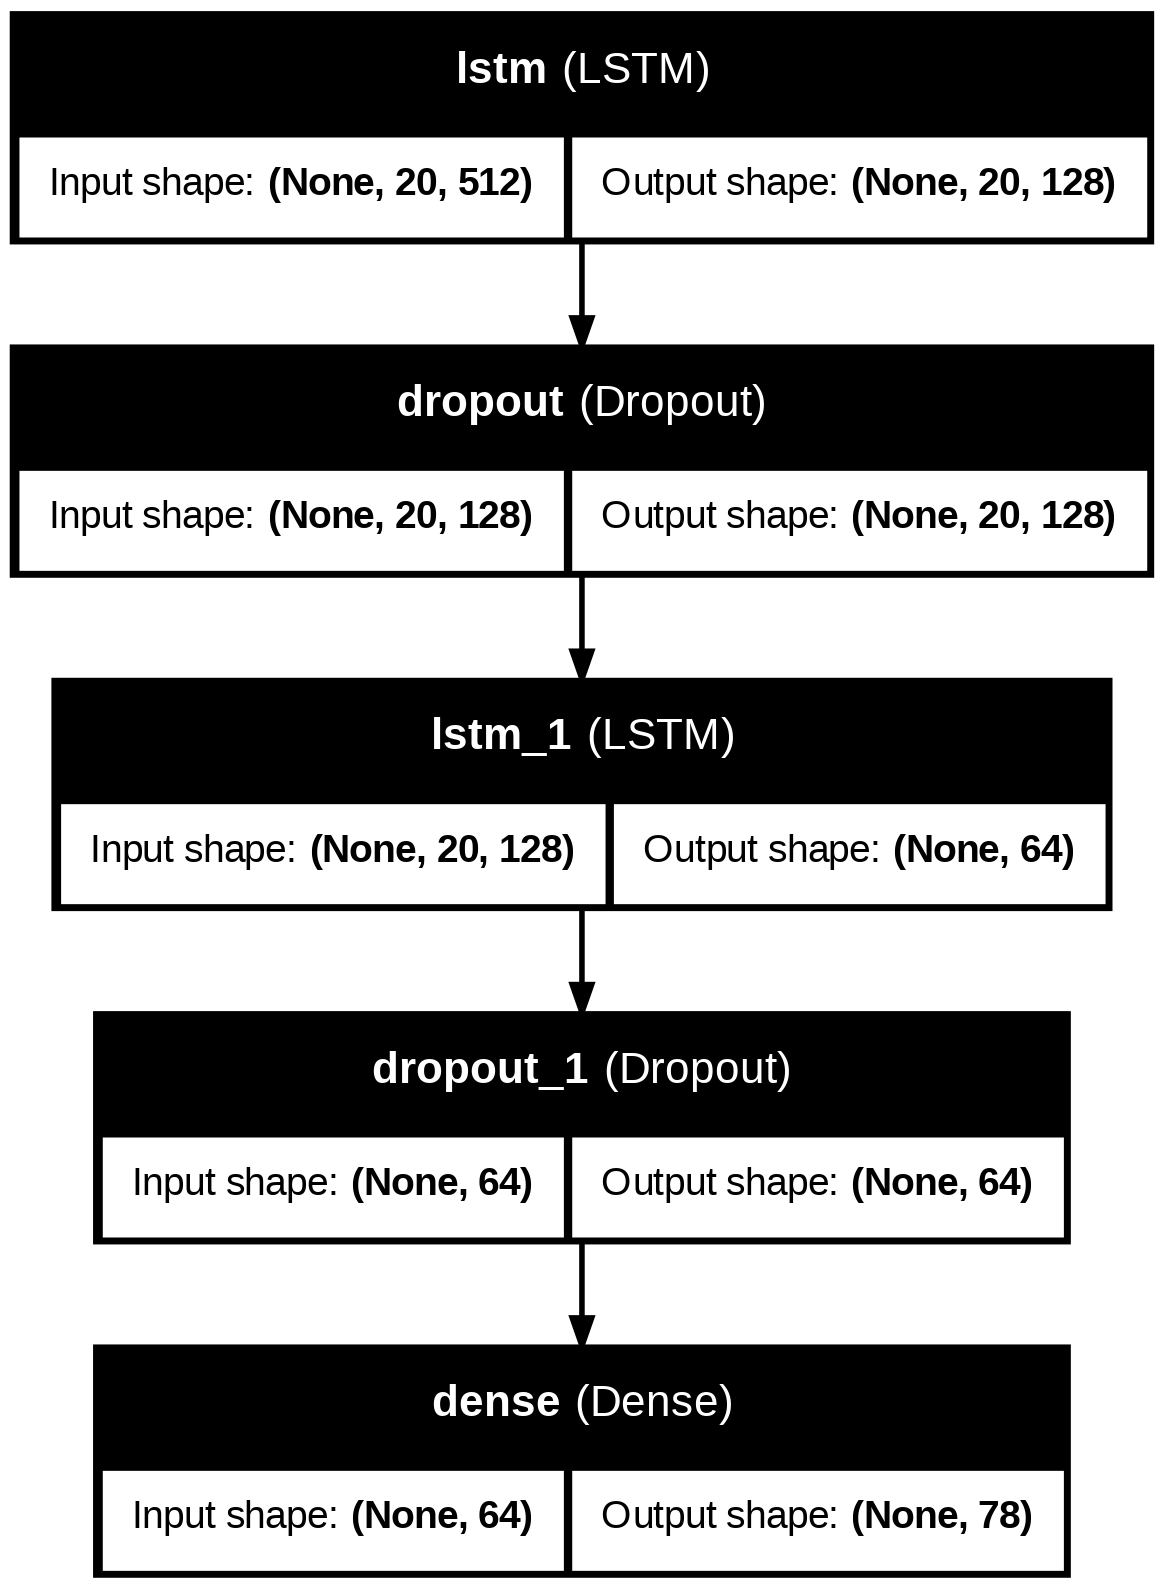

In [ ]:
# Plot cấu trúc của mô hình CLIP-LRCN.
plot_model(clip_lrcn_model, to_file='CLIP_LRCN_model_structure_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# Tạo một thực thể của Callback Early Stopping.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)



# Biên dịch mô hình và chỉ định hàm mất mát, tối ưu hóa và các chỉ số cho mô hình.
clip_lrcn_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=["accuracy"])

# Bắt đầu huấn luyện mô hình với đặc trưng CLIP
clip_lrcn_model_training_history = clip_lrcn_model.fit(
    x=clip_features_train,
    y=labels_train,
    epochs=100,
    batch_size=4,  # Giảm batch size xuống 4
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

Epoch 1/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.2358 - loss: 3.7198 - val_accuracy: 0.7263 - val_loss: 1.7951
Epoch 2/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7050 - loss: 1.6717 - val_accuracy: 0.8204 - val_loss: 1.0866
Epoch 3/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8206 - loss: 1.0619 - val_accuracy: 0.8820 - val_loss: 0.7416
Epoch 4/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.8828 - loss: 0.7366 - val_accuracy: 0.9047 - val_loss: 0.5414
Epoch 5/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.9161 - loss: 0.5400 - val_accuracy: 0.9293 - val_loss: 0.4098
Epoch 6/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9393 - loss: 0.3986 - val_accuracy: 0.9254 - val_loss: 0.3508
Epoch 7/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9518 - loss: 0.3063 - val_accuracy: 0.9501 - val_loss: 0.2625
Epoch 8/100
1541/1541 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 

In [ ]:
# Đánh giá mô hình đã huấn luyện.
model_evaluation_history = clip_lrcn_model.evaluate(clip_features_test, labels_test)

# Lấy giá trị mất mát và độ chính xác từ model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9852 - loss: 0.0634


In [ ]:
# Lấy giá trị mất mát và độ chính xác từ model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Định dạng chuỗi ngày tháng.
date_time_format = '%Y_%m_%d__%H_%M_%S'

# Lấy ngày và giờ hiện tại dưới dạng một đối tượng DateTime.
current_date_time_dt = dt.datetime.now()

# Chuyển đổi đối tượng DateTime thành một chuỗi theo định dạng được chỉ định trong chuỗi date_time_format.
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Định nghĩa một tên hữu ích cho mô hình của chúng ta để dễ dàng trong việc điều hướng qua nhiều mô hình đã lưu.
model_file_name = f'CLIP_LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss:.4f}___Accuracy_{model_evaluation_accuracy:.4f}.h5'

# Lưu mô hình.
clip_lrcn_model.save(model_file_name)

In [ ]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):

    # Lấy giá trị của metric sử dụng tên metric làm điểm nhận dạng.
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    # Xây dựng một đối tượng phạm vi sẽ được sử dụng làm trục x (phương ngang) của biểu đồ.
    epochs = range(len(metric_value_1))

    # Vẽ biểu đồ.
    plt.plot(epochs, metric_value_1, 'blue', label=metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label=metric_name_2)

    # Thêm tiêu đề vào biểu đồ.
    plt.title(str(plot_name))

    # Thêm chú thích vào biểu đồ.
    plt.legend()

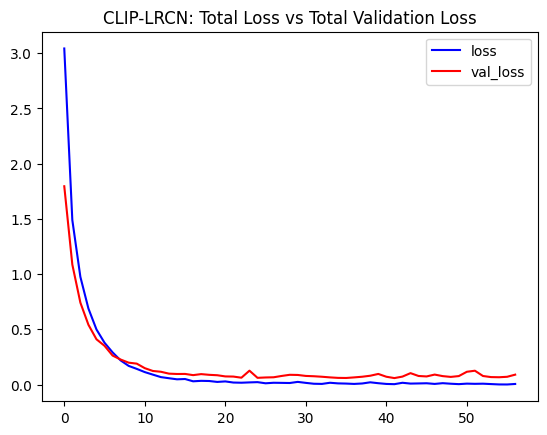

In [ ]:
# Visualize the training and validation loss metrics.
plot_metric(clip_lrcn_model_training_history, 'loss', 'val_loss', 'CLIP-LRCN: Total Loss vs Total Validation Loss')



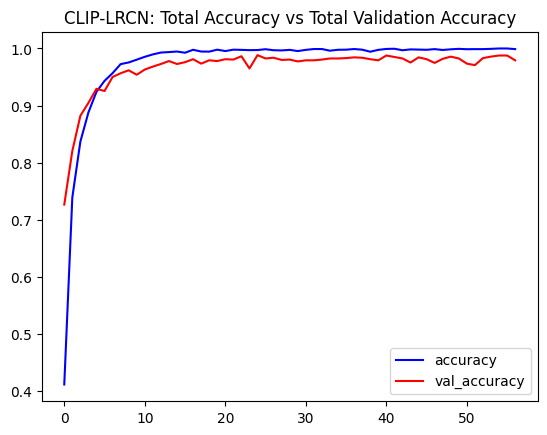

In [ ]:
# Visualize the training and validation accuracy metrics.
plot_metric(clip_lrcn_model_training_history, 'accuracy', 'val_accuracy', 'CLIP-LRCN: Total Accuracy vs Total Validation Accuracy')

81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
                   precision    recall  f1-score   support

   ApplyEyeMakeup       1.00      0.93      0.96        40
    ApplyLipstick       1.00      1.00      1.00        30
          Archery       1.00      0.97      0.99        35
     BabyCrawling       1.00      1.00      1.00        28
     BandMarching       1.00      1.00      1.00        31
    BaseballPitch       1.00      0.97      0.99        40
       Basketball       0.97      1.00      0.99        38
   BasketballDunk       1.00      0.96      0.98        27
       BenchPress       1.00      1.00      1.00        43
           Biking       1.00      0.97      0.99        38
        Billiards       1.00      1.00      1.00        36
      BlowDryHair       0.92      0.96      0.94        24
   BlowingCandles       1.00      1.00      1.00        19
 BodyWeightSquats       0.96      1.00      0.98        23
          Bowling       1.00      0.98      0.99        43
BoxingPunchingB

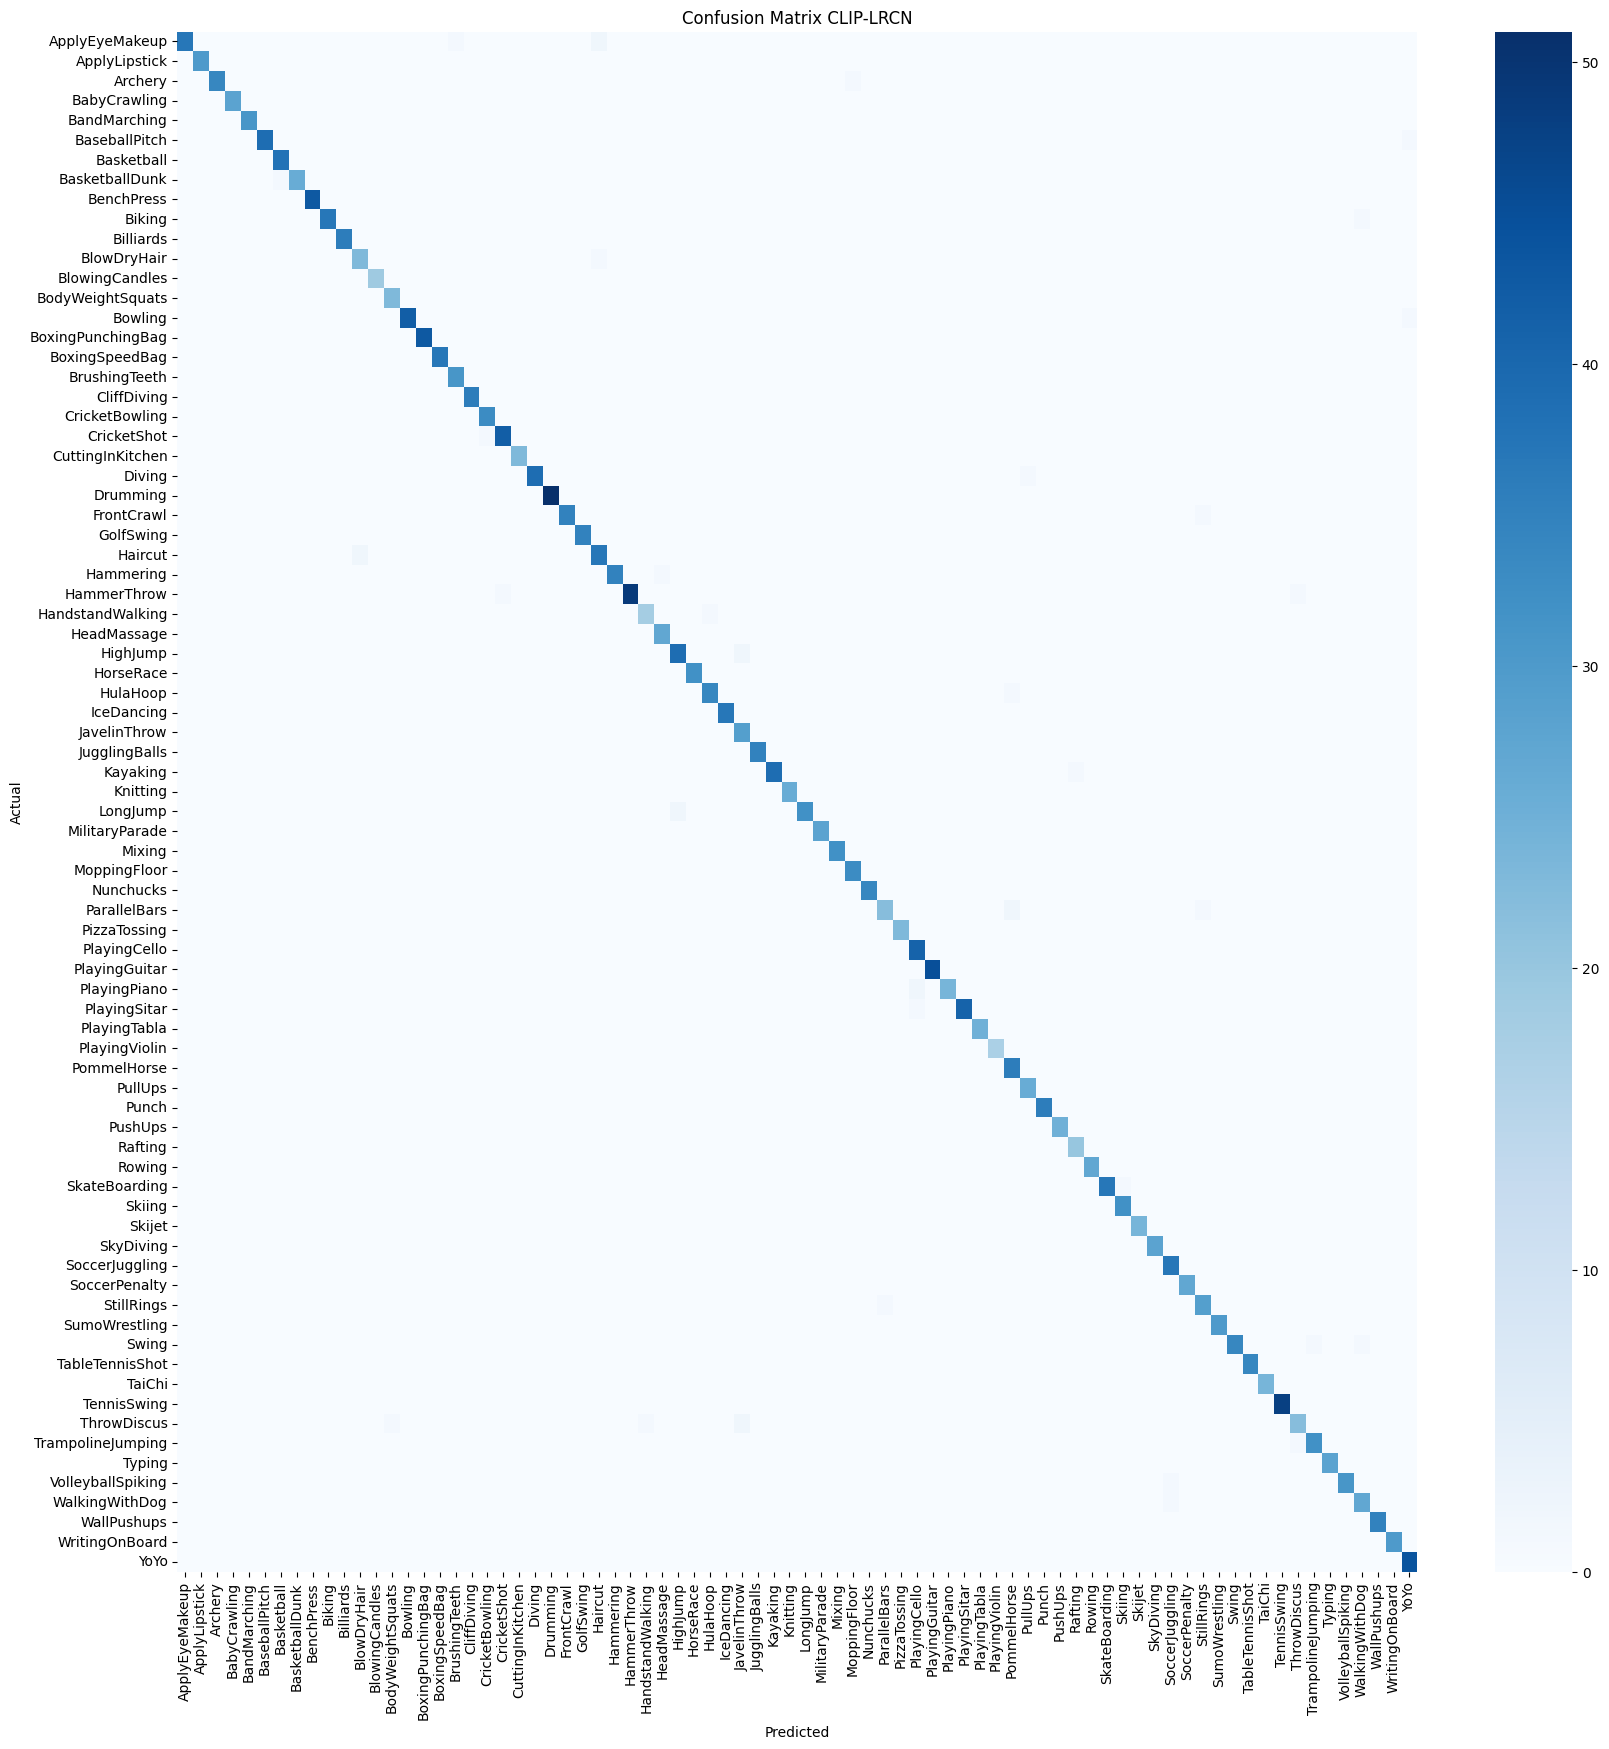

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict tập test
y_pred = clip_lrcn_model.predict(clip_features_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(labels_test, axis=1)

# In classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES_LIST))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=CLASSES_LIST, yticklabels=CLASSES_LIST)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix CLIP-LRCN")
plt.show()


In [ ]:
pip install youtube-dl moviepy opencv-python ffmpeg-python


In [ ]:
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.2/172.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.5 MB/s eta 0:00:00


In [ ]:
import yt_dlp
import cv2
import os
import numpy as np

def download_youtube_video(url, save_path='TruotVan2.mp4', cookies_path='cookies.txt'):
    """Tải video từ YouTube bằng yt-dlp với file cookies."""
    ydl_opts = {
    'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]',  # Chỉ tải MP4
    'outtmpl': f'{save_path}',  # Lưu file với đuôi .mp4
    'cookiefile': cookies_path,
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'quiet': False
}


    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([url])
        print(f"✅ Video đã được tải về: {save_path}")
        return save_path
    except Exception as e:
        print(f"❌ Lỗi khi tải video: {e}")
        return None

# Ví dụ sử dụng
video_url = "https://www.youtube.com/shorts/Pz_Wh0y8fYs"
cookies_path = "cookies.txt"  # Đảm bảo file cookies.txt có sẵn
video_path = download_youtube_video(video_url, cookies_path=cookies_path)


[youtube] Extracting URL: https://www.youtube.com/shorts/Pz_Wh0y8fYs
[youtube] Pz_Wh0y8fYs: Downloading webpage
[youtube] Pz_Wh0y8fYs: Downloading tv client config
[youtube] Pz_Wh0y8fYs: Downloading player 9599b765-main
[youtube] Pz_Wh0y8fYs: Downloading tv player API JSON
[youtube] Pz_Wh0y8fYs: Downloading ios player API JSON
[youtube] Pz_Wh0y8fYs: Downloading m3u8 information
[info] Pz_Wh0y8fYs: Downloading 1 format(s): 398+140
[download] Destination: TruotVan2.f398.mp4
[download] 100% of    4.14MiB in 00:00:00 at 9.58MiB/s   
[download] Destination: TruotVan2.f140.m4a
[download] 100% of  553.85KiB in 00:00:00 at 3.72MiB/s   
[Merger] Merging formats into "TruotVan2.mp4"
Deleting original file TruotVan2.f398.mp4 (pass -k to keep)
Deleting original file TruotVan2.f140.m4a (pass -k to keep)
✅ Video đã được tải về: TruotVan2.mp4


In [ ]:
def predict_with_clip_lrcn(video_file_path):
    """Dự đoán hành động trên video sử dụng mô hình CLIP-LRCN."""

    # Trích xuất khung hình từ video
    frames = frames_extraction(video_file_path)

    # Chuyển danh sách khung hình thành mảng numpy
    frames_array = np.array(frames)

    # Trích xuất đặc trưng CLIP
    clip_features = extract_clip_features(frames_array, clip_model, clip_preprocess, device)

    # Chuẩn bị dữ liệu đầu vào cho mô hình
    clip_features = np.expand_dims(clip_features, axis=0)

    # Dự đoán
    predicted_labels_probabilities = clip_lrcn_model.predict(clip_features)[0]
    predicted_label = np.argmax(predicted_labels_probabilities)
    predicted_class_name = CLASSES_LIST[predicted_label]
    confidence = predicted_labels_probabilities[predicted_label]

    print(f'Hành động dự đoán: {predicted_class_name}')
    print(f'Độ tin cậy: {confidence}')